In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
%cd "/content/drive/MyDrive/Master's Thesis/TM Project/"

/content/drive/MyDrive/Master's Thesis/TM Project


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# !pip install scikit-optimize

In [4]:
# from skopt import gp_minimize
# from skopt import space

In [174]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from scipy.io import loadmat

In [162]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1
# spacing
# dx = (0.0952/1.55) * k_0
# dy =  (0.05/1.55) * k_0

dx = (0.0952/1.55) * k_0
dy =  (0.05/1.55) * k_0
# simulation lengths

core_length_x = ((2/1.55) * lambd) * k_0 # W
core_length_y = ((1.1/1.55) * lambd) * k_0 # H

substrate_length_x = ((3.0/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((5.025/1.55) * lambd) * k_0 # Ys

rib_length = ((0.2/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.525/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.34
n_cladding = 1

In [163]:
study = 'scalar'

In [164]:
memory_type = torch.device('cpu')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [165]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [166]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [148]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()

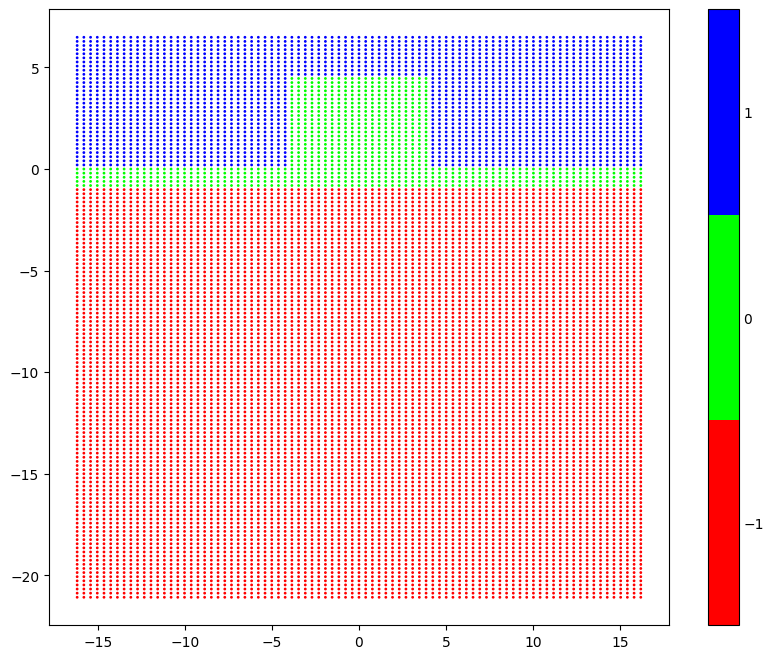

In [149]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[-1, 0, 1])
cb.ax.tick_params(length=0)

In [150]:
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)

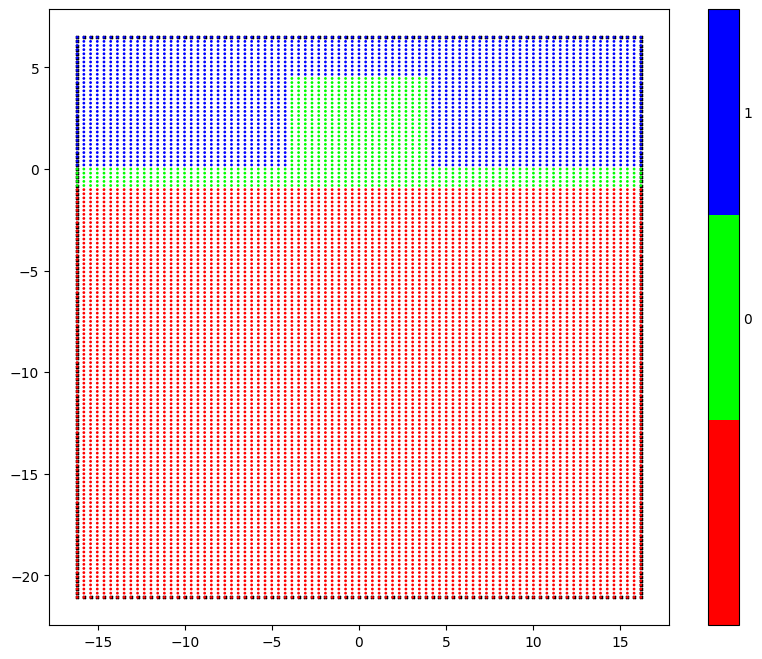

In [151]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black');
plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [152]:
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-153-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-153-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


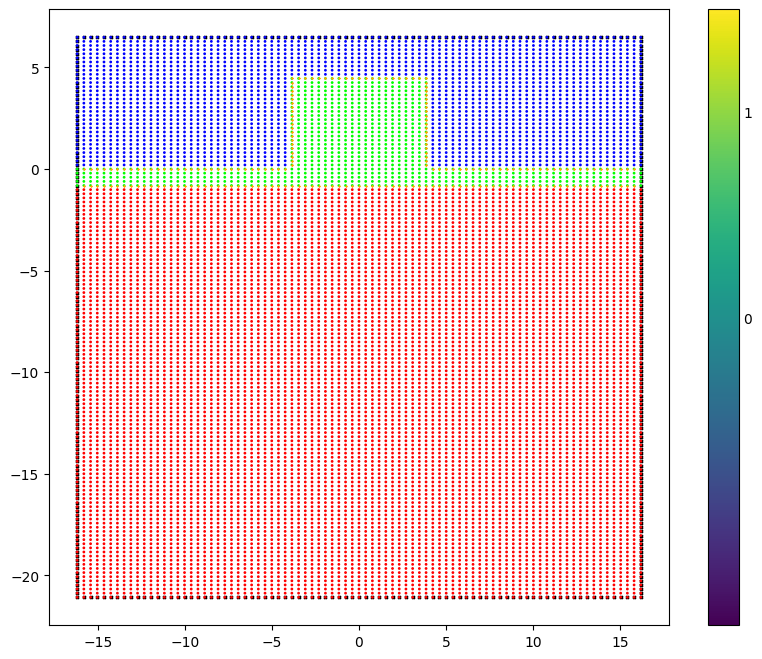

In [153]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [175]:
study = 'scalar'

In [176]:
memory_type = torch.device('cpu')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [177]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 64, num_modes, 2, 'Swish')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4481


In [178]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

0.00021353361080400646


In [179]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [180]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 11645


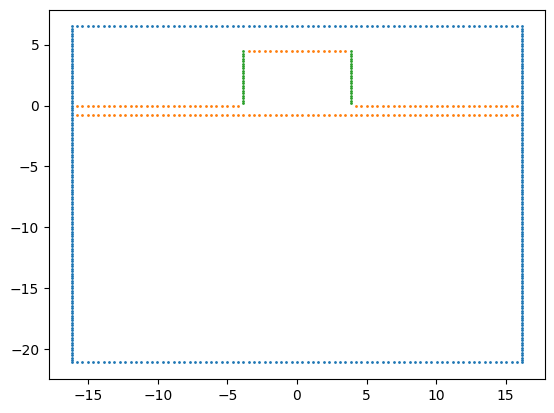

iteration 1 loss1 is 1.83159, loss2 is 253.20543, loss3 is 2.65391, loss4 is 0.0, loss5 is 1.83387, loss6 is 0.90578, total loss 4.571244716644287
3.268890619277954


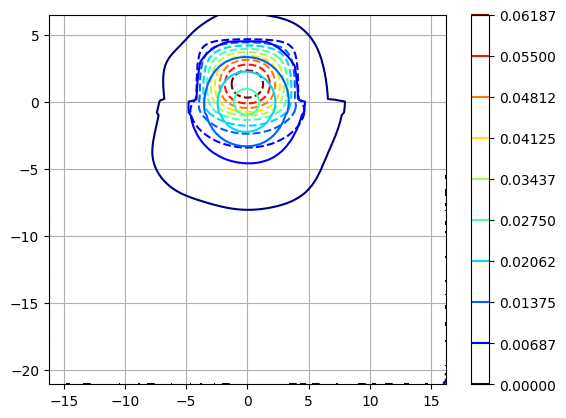

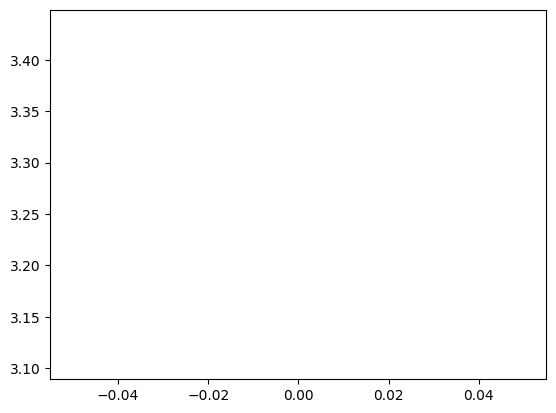

iteration 1001 loss1 is 0.02993, loss2 is 0.00863, loss3 is 0.50026, loss4 is 0.0, loss5 is 0.00124, loss6 is 0.02452, total loss 0.05569104105234146
3.390316963195801


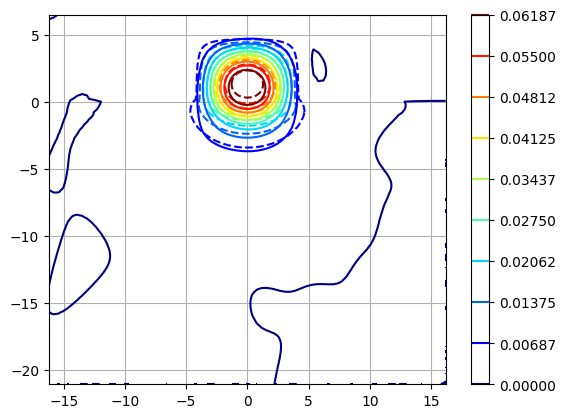

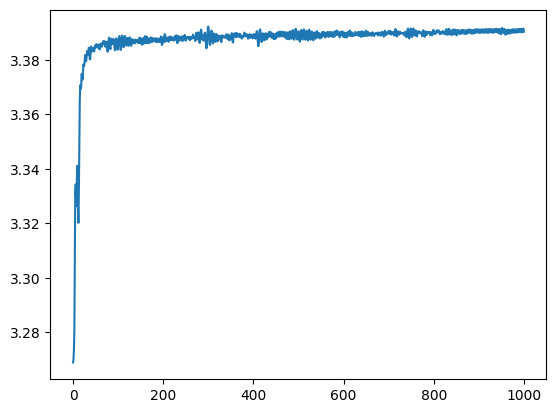

iteration 2001 loss1 is 0.02342, loss2 is 0.00039, loss3 is 0.49265, loss4 is 0.0, loss5 is 0.00077, loss6 is 0.02422, total loss 0.0484197661280632
3.3918609619140625


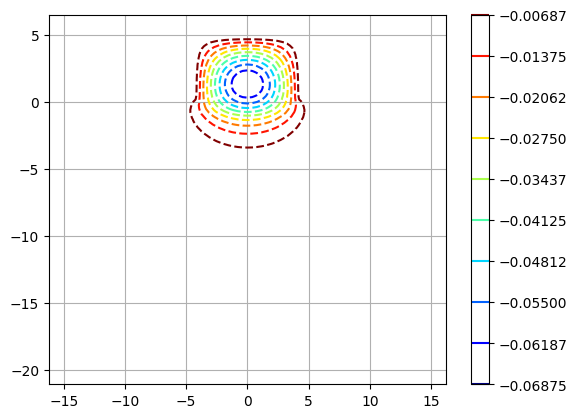

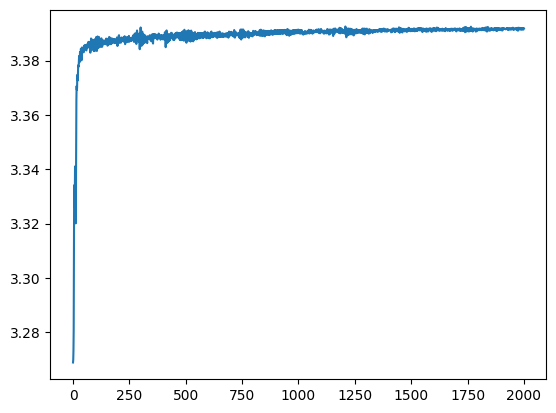

KeyboardInterrupt: 

In [181]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1/2, 1, 1, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [61]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=64, bias=True)
  (1): SiLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): SiLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)

In [62]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

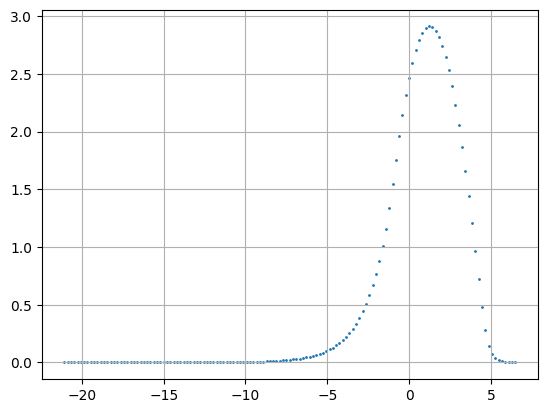

In [63]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [64]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

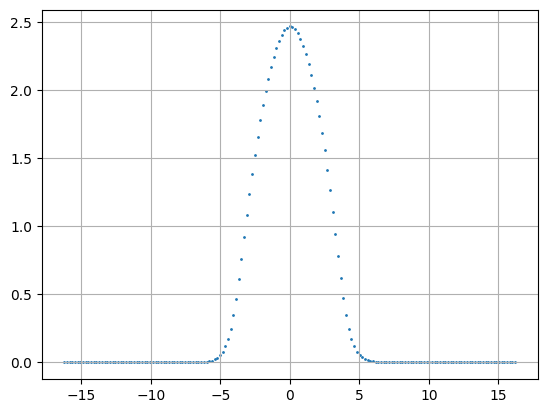

In [65]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [66]:
study = 'TE'

In [85]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [86]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 64, num_modes, 2, 'Swish')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4481


In [87]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

0.00021353308693505824


In [88]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [89]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 11645


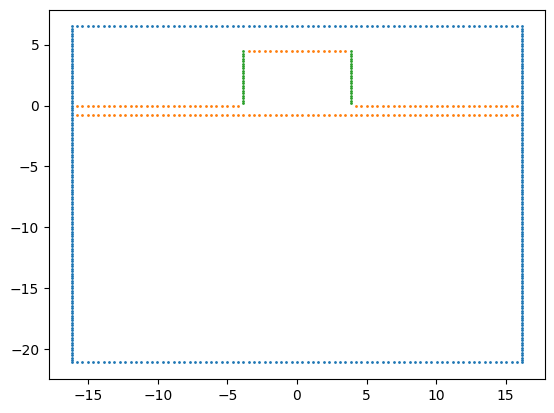

iteration 1 loss1 is 1.83159, loss2 is 253.20549, loss3 is 2.65388, loss4 is 0.0, loss5 is 1.83387, loss6 is 14.62097, total loss 18.28643226623535
3.268890857696533


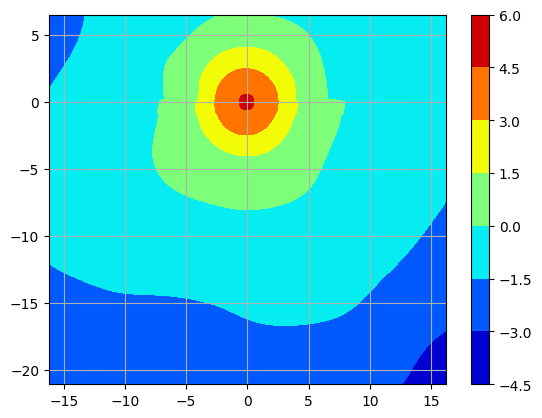

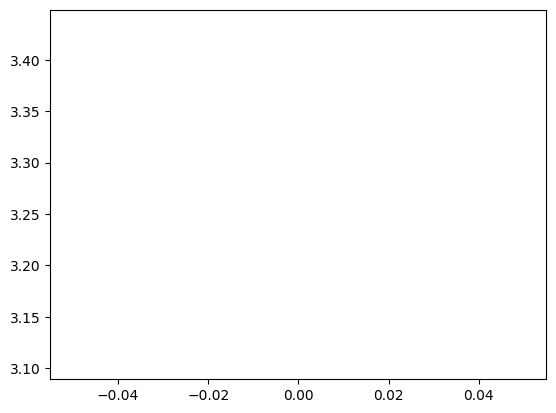

iteration 1001 loss1 is 0.03865, loss2 is 0.01842, loss3 is 0.57028, loss4 is 0.0, loss5 is 0.00282, loss6 is 0.20288, total loss 0.24435073137283325
3.378023386001587


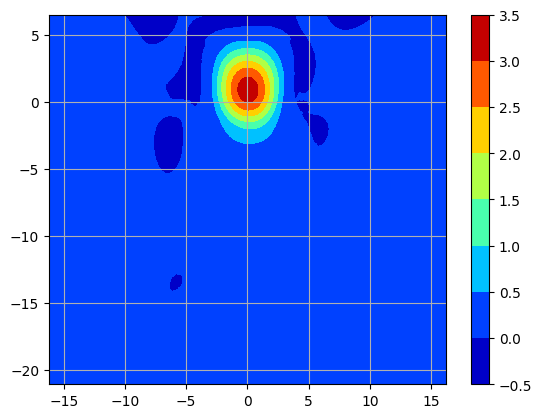

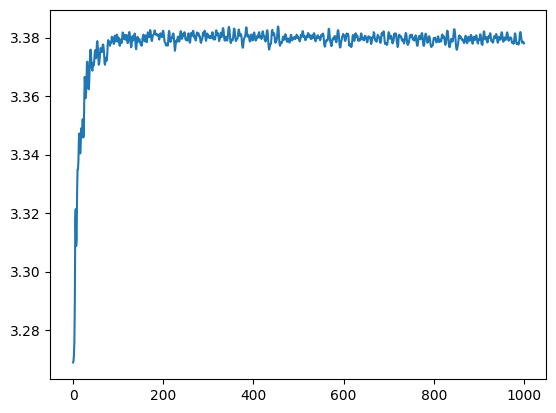

iteration 2001 loss1 is 0.03338, loss2 is 0.00293, loss3 is 0.54828, loss4 is 0.0, loss5 is 0.00214, loss6 is 0.07153, total loss 0.10704608261585236
3.3815526962280273


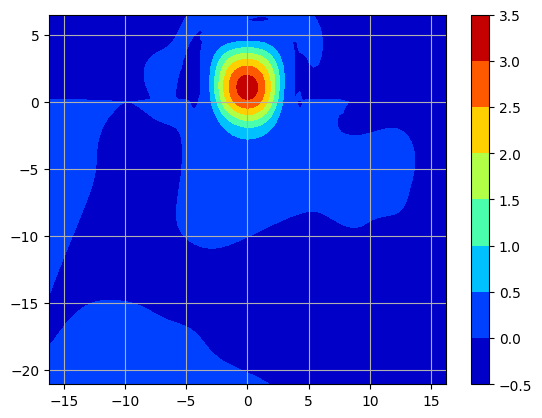

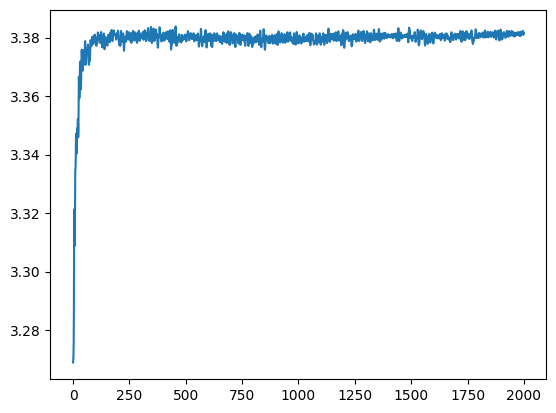

iteration 3001 loss1 is 0.0336, loss2 is 0.0007, loss3 is 0.53791, loss4 is 0.0, loss5 is 0.00195, loss6 is 0.09259, total loss 0.12813854217529297
3.383315086364746


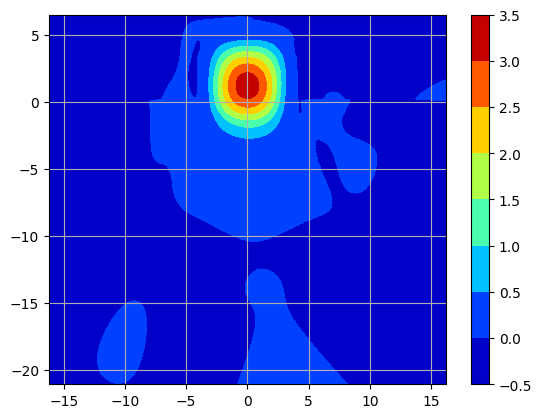

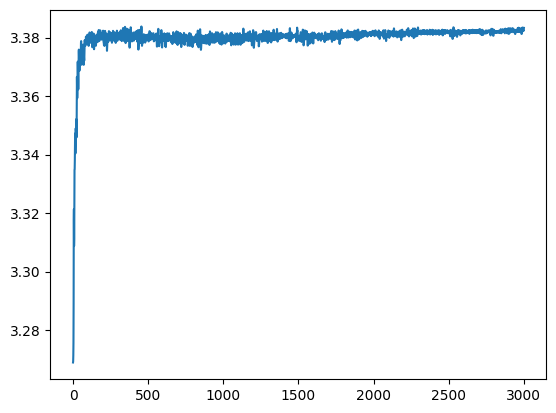

iteration 4001 loss1 is 0.02908, loss2 is 0.00023, loss3 is 0.53665, loss4 is 0.0, loss5 is 0.00023, loss6 is 0.03095, total loss 0.06025882065296173
3.3835337162017822


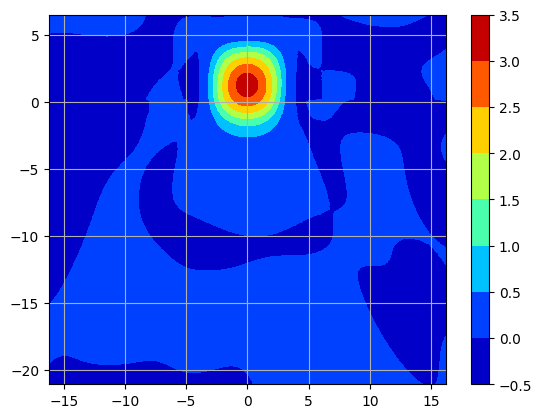

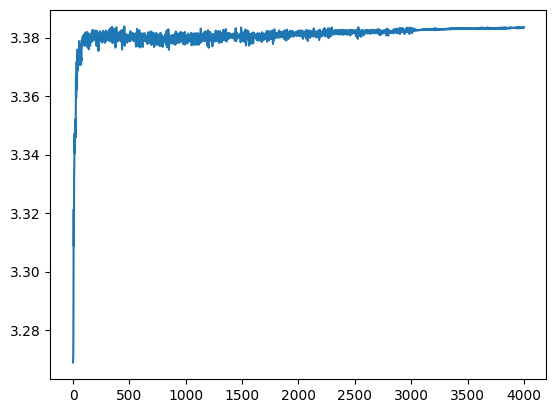

iteration 5001 loss1 is 0.02921, loss2 is 0.0005, loss3 is 0.53595, loss4 is 0.0, loss5 is 0.00016, loss6 is 0.01101, total loss 0.040372006595134735
3.383655309677124


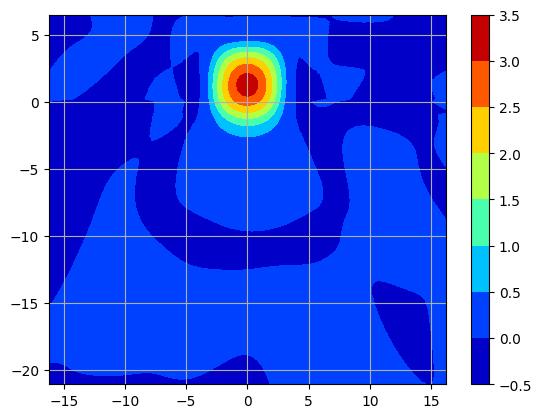

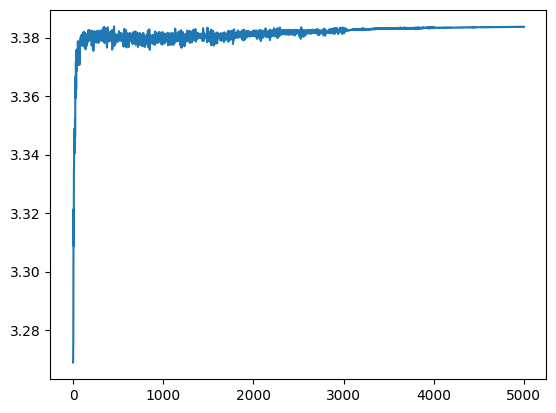

iteration 6001 loss1 is 0.02924, loss2 is 0.0004, loss3 is 0.53545, loss4 is 0.0, loss5 is 0.00013, loss6 is 0.00905, total loss 0.038427211344242096
3.3837430477142334


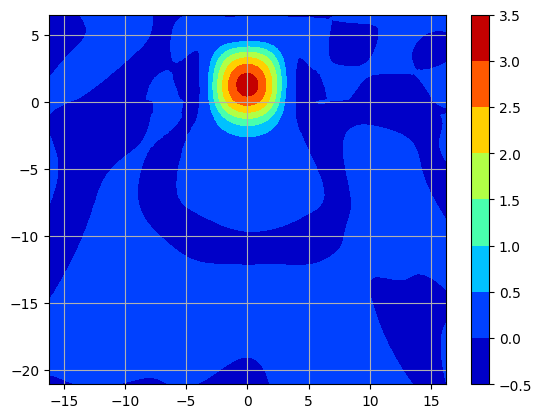

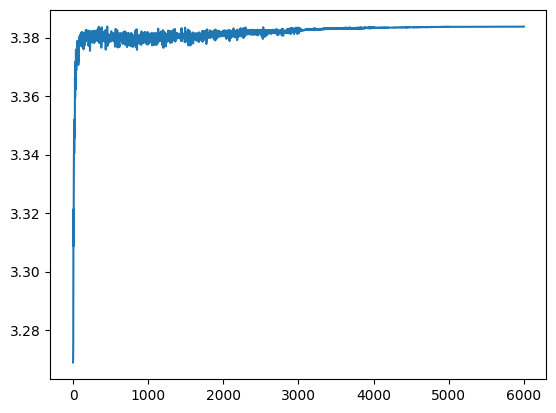

iteration 7001 loss1 is 0.02917, loss2 is 0.00041, loss3 is 0.5351, loss4 is 0.0, loss5 is 0.00012, loss6 is 0.00896, total loss 0.03825448825955391
3.383803606033325


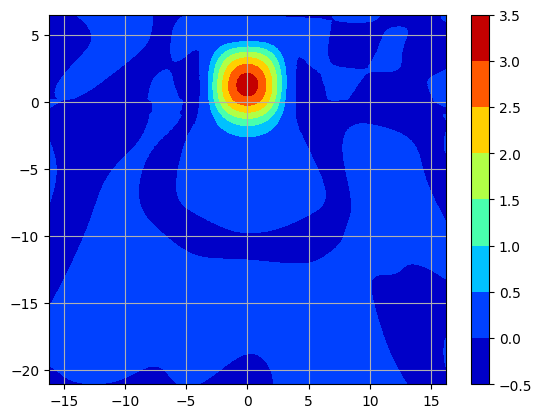

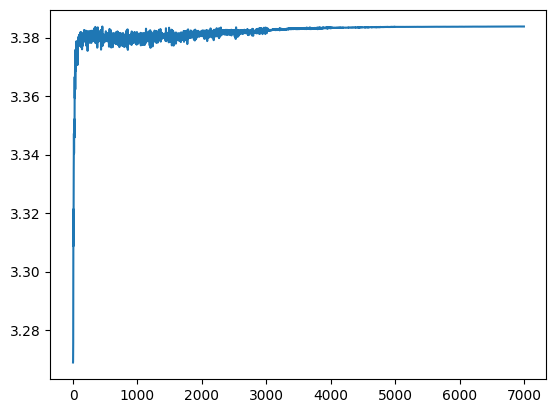

iteration 8001 loss1 is 0.02907, loss2 is 0.00041, loss3 is 0.53479, loss4 is 0.0, loss5 is 0.00012, loss6 is 0.00858, total loss 0.03777335211634636
3.383857488632202


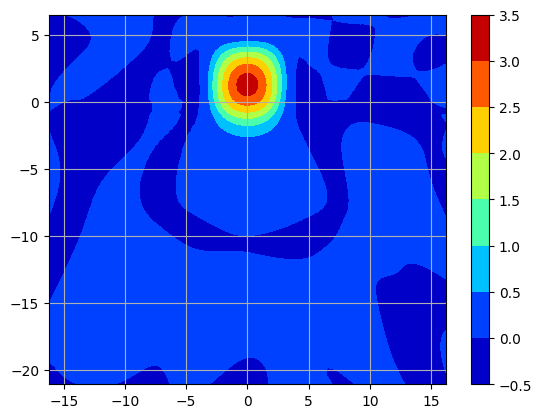

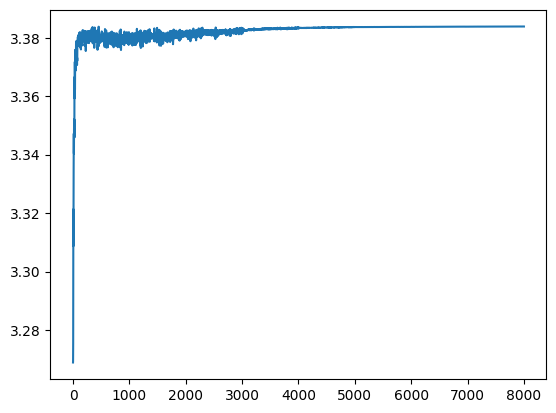

iteration 9001 loss1 is 0.02899, loss2 is 0.00039, loss3 is 0.53448, loss4 is 0.0, loss5 is 0.00012, loss6 is 0.00905, total loss 0.03815643861889839
3.3839128017425537


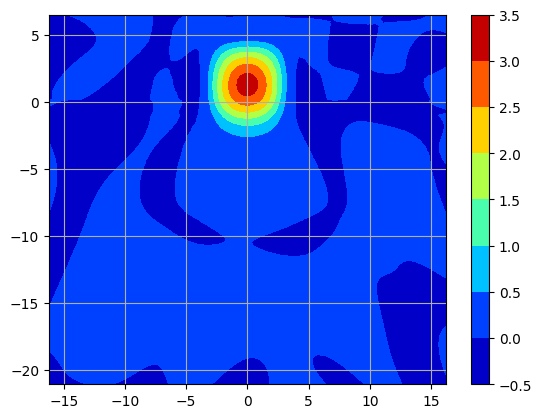

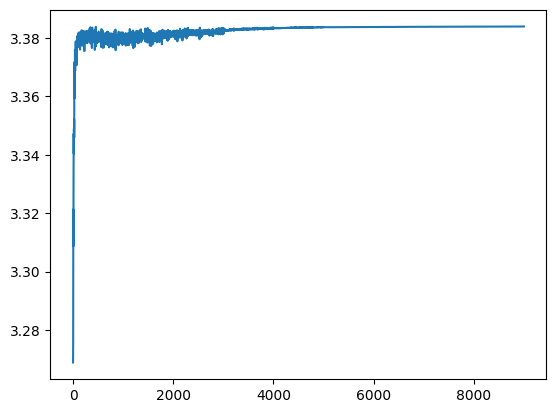

iteration 10001 loss1 is 0.02893, loss2 is 0.0004, loss3 is 0.53428, loss4 is 0.0, loss5 is 0.00011, loss6 is 0.00839, total loss 0.0374363549053669
3.3839471340179443


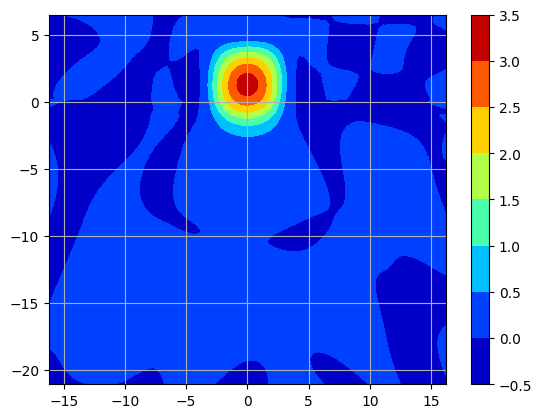

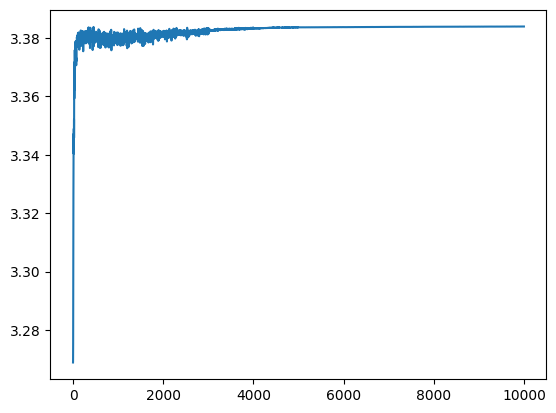

In [90]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1/2, 1, 1, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [91]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=64, bias=True)
  (1): SiLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): SiLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)

In [92]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

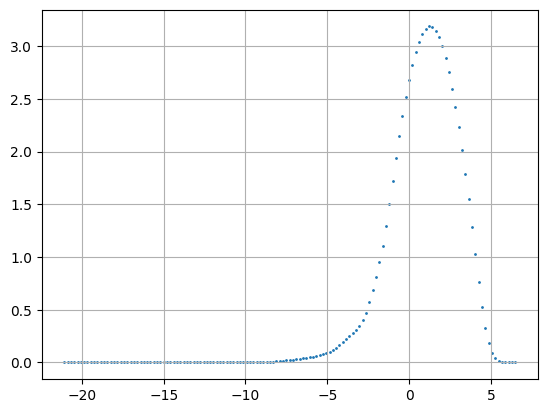

In [93]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [94]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

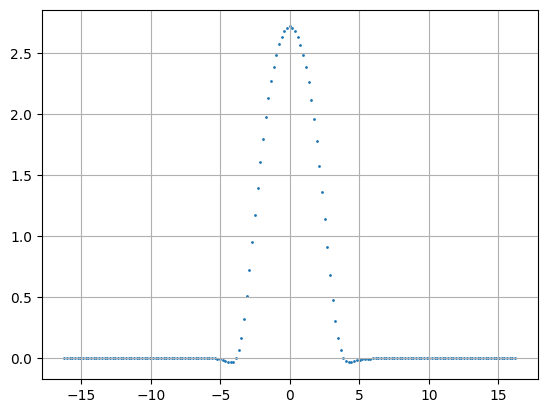

In [95]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [170]:
study = 'TM'

In [171]:
memory_type = torch.device('cuda')
dtype = torch.float32
torch.manual_seed(42)
num_modes = 1

In [172]:
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 64, num_modes, 2, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4609


In [173]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

7.862586789997295e-05


In [174]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [175]:
train_agent = trainers.Trainer2D(dtype, device, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 11645


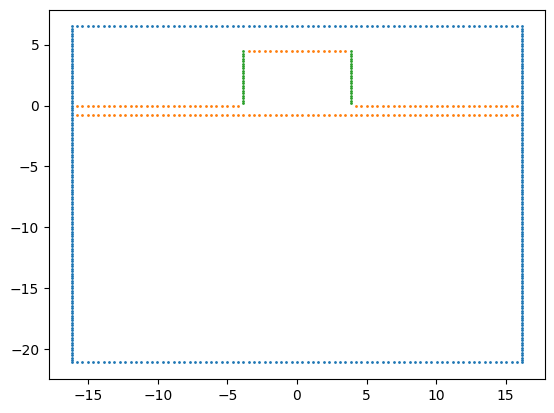

iteration 1 loss1 is 1.92975, loss2 is 59.92437, loss3 is 11.73246, loss4 is 0.0, loss5 is 0.86055, loss6 is 5.68775, total loss 8.478047370910645
3.1723077297210693


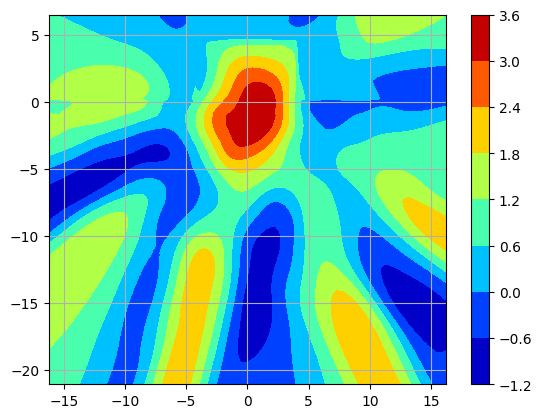

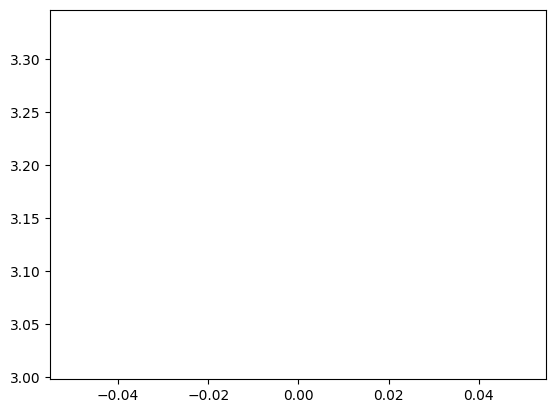

iteration 1001 loss1 is 0.0438, loss2 is 0.04345, loss3 is 0.52239, loss4 is 0.0, loss5 is 0.0072, loss6 is 0.12359, total loss 0.17459601163864136
3.386079788208008


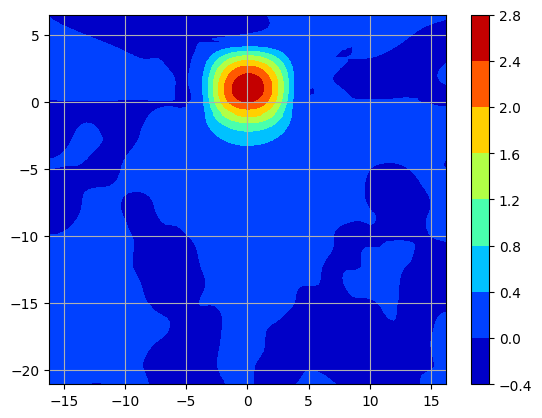

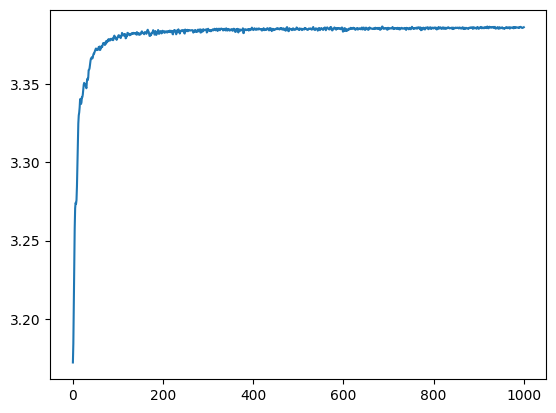

iteration 2001 loss1 is 0.03049, loss2 is 0.02563, loss3 is 0.51552, loss4 is 0.0, loss5 is 0.0047, loss6 is 0.09008, total loss 0.12527556717395782
3.387357234954834


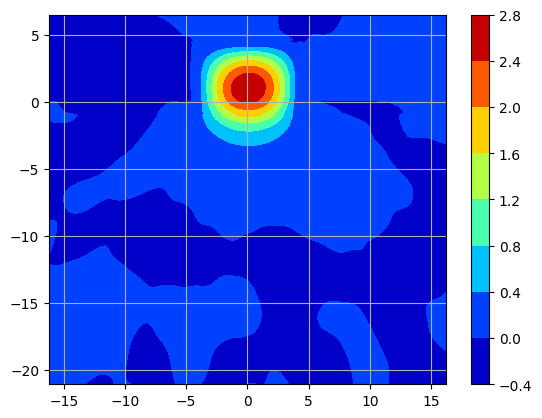

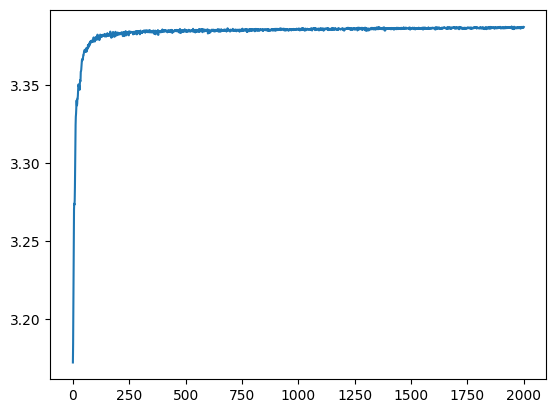

iteration 3001 loss1 is 0.03176, loss2 is 0.01944, loss3 is 0.51406, loss4 is 0.0, loss5 is 0.00532, loss6 is 0.11916, total loss 0.1562393605709076
3.387631893157959


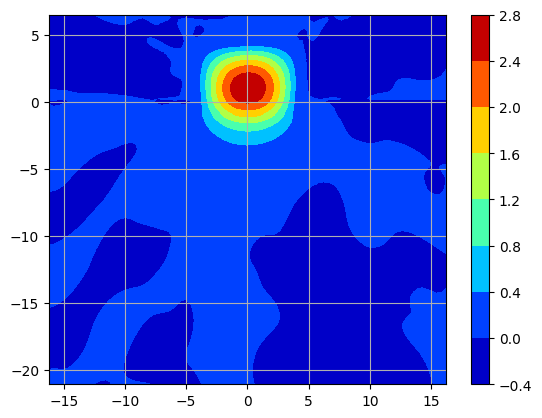

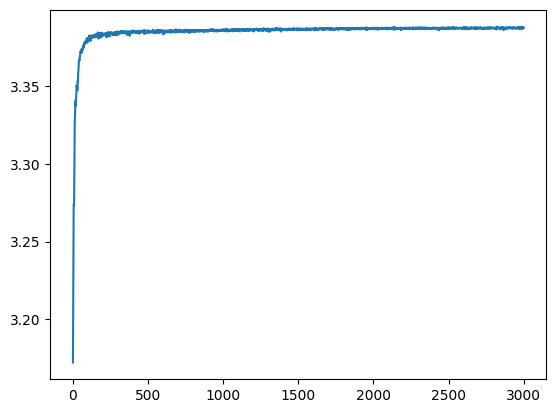

iteration 4001 loss1 is 0.01968, loss2 is 0.00566, loss3 is 0.51452, loss4 is 0.0, loss5 is 0.00196, loss6 is 0.04548, total loss 0.06712523102760315
3.387545585632324


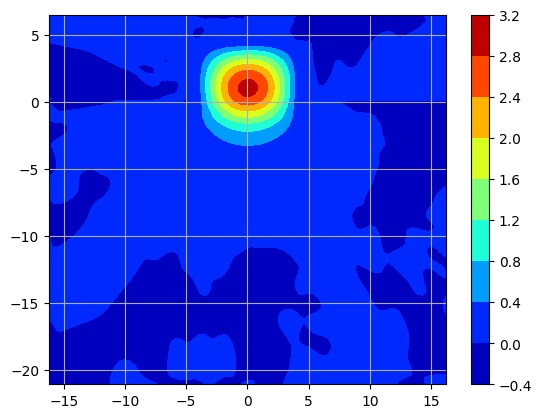

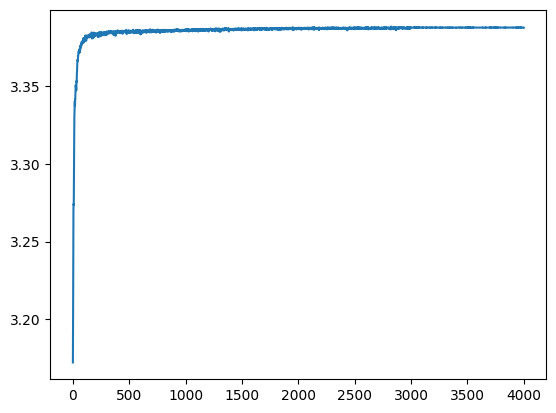

iteration 5001 loss1 is 0.01567, loss2 is 0.00402, loss3 is 0.51416, loss4 is 0.0, loss5 is 0.00116, loss6 is 0.032, total loss 0.04882560297846794
3.3876147270202637


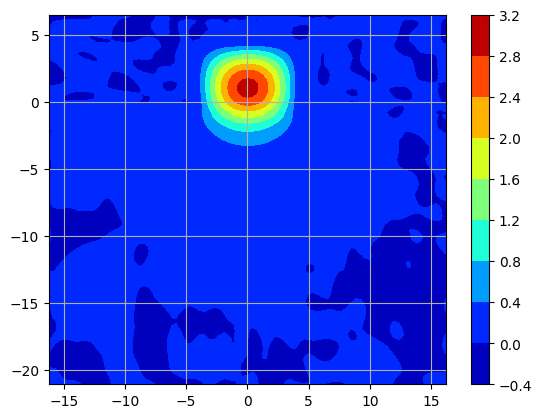

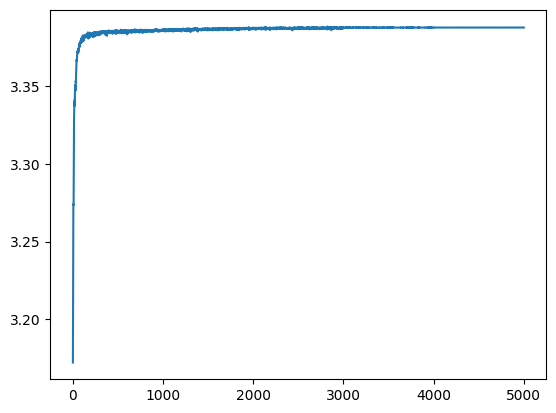

iteration 6001 loss1 is 0.01534, loss2 is 0.00385, loss3 is 0.51413, loss4 is 0.0, loss5 is 0.00113, loss6 is 0.02922, total loss 0.04569312930107117
3.3876192569732666


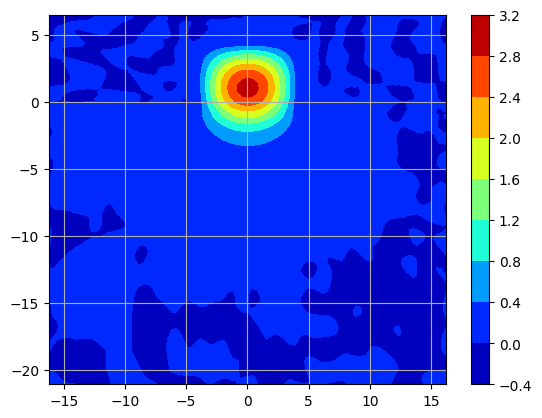

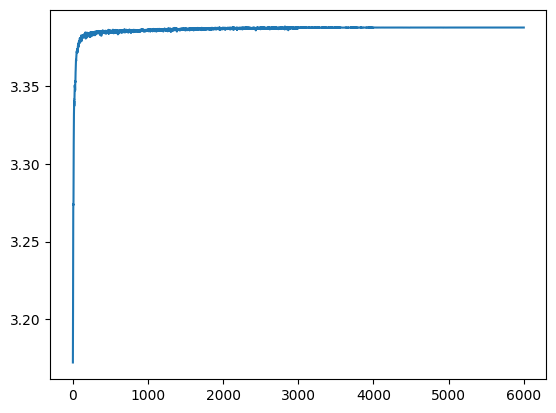

iteration 7001 loss1 is 0.01519, loss2 is 0.00371, loss3 is 0.51409, loss4 is 0.0, loss5 is 0.00109, loss6 is 0.02892, total loss 0.04520483314990997
3.3876278400421143


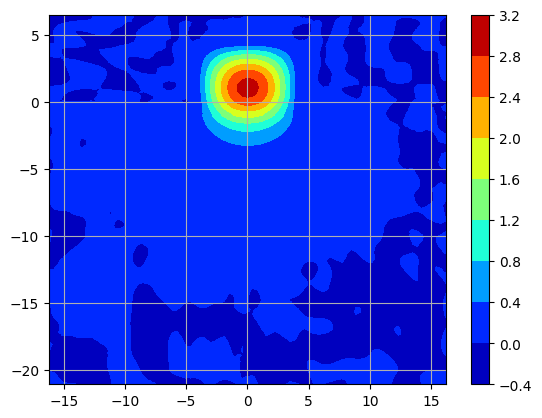

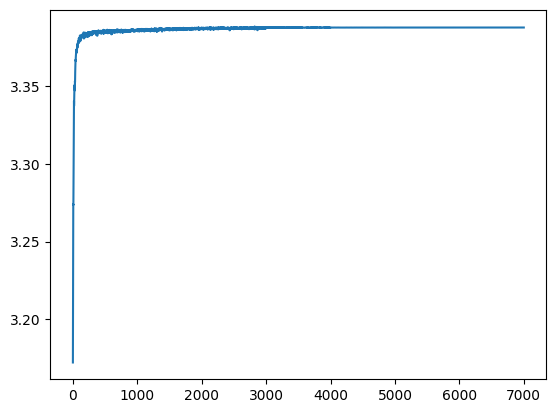

iteration 8001 loss1 is 0.01505, loss2 is 0.00364, loss3 is 0.51406, loss4 is 0.0, loss5 is 0.00107, loss6 is 0.02902, total loss 0.04514055326581001
3.3876335620880127


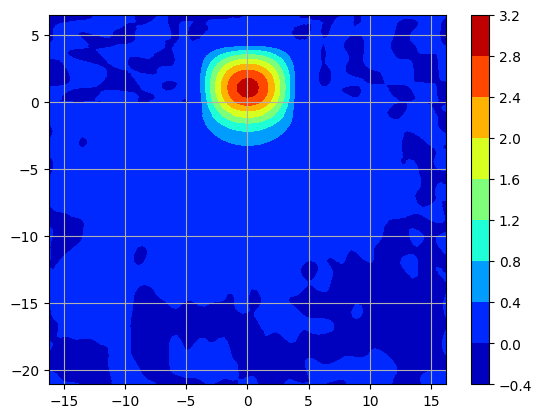

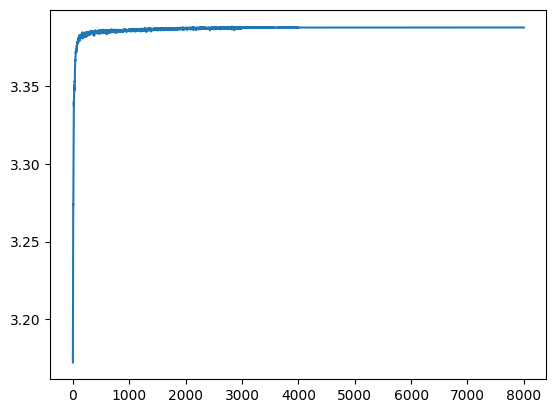

iteration 9001 loss1 is 0.01491, loss2 is 0.00359, loss3 is 0.51402, loss4 is 0.0, loss5 is 0.00106, loss6 is 0.02905, total loss 0.045009586960077286
3.3876397609710693


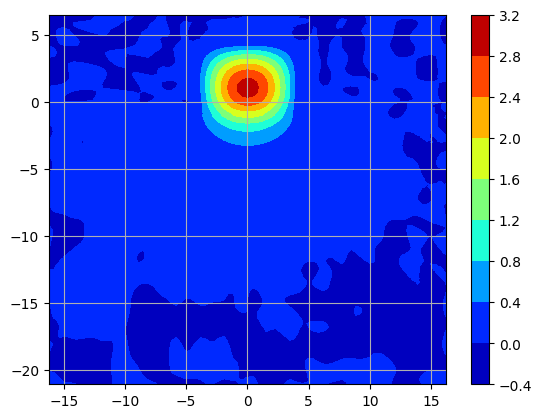

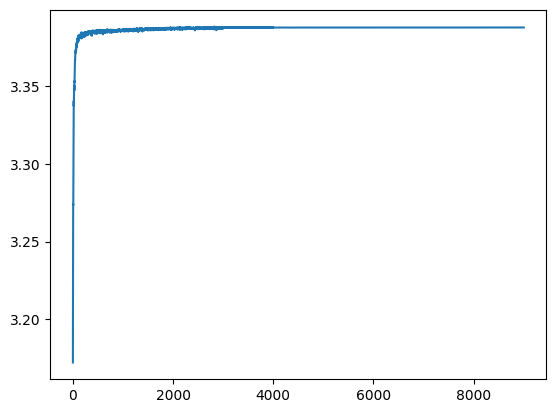

iteration 10001 loss1 is 0.01477, loss2 is 0.00355, loss3 is 0.514, loss4 is 0.0, loss5 is 0.00102, loss6 is 0.02888, total loss 0.044661350548267365
3.3876450061798096


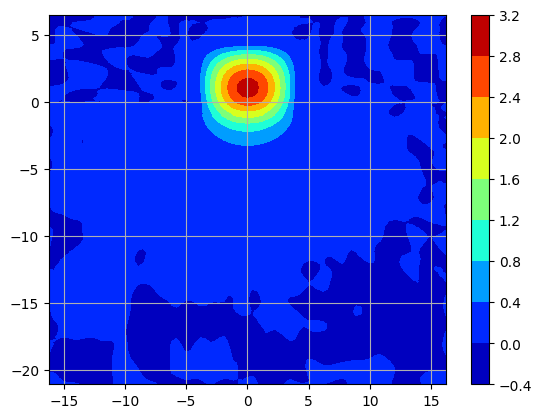

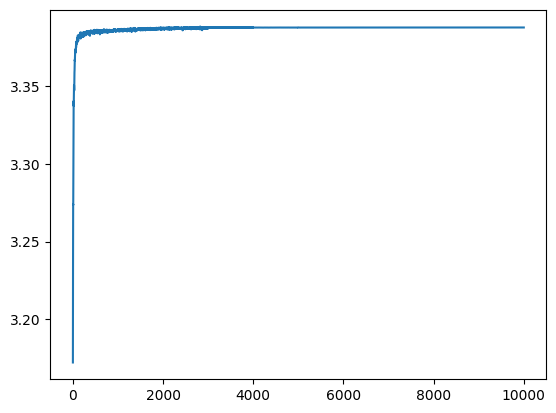

In [176]:
# loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1, 1, 1, 1, 1, 1], verbose=1, sample_new=False)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[5, 1/2, 1, 1, 1, 1], verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [160]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=64, bias=True)
  (1): SiLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): SiLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)

In [161]:
yu = torch.arange(0, reference_device.upward_length, dy/2, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy/2, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

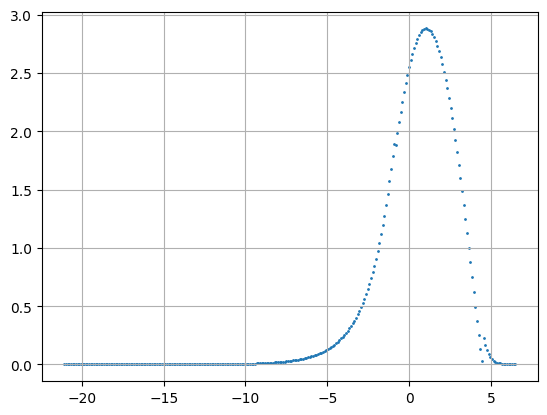

In [162]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [106]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

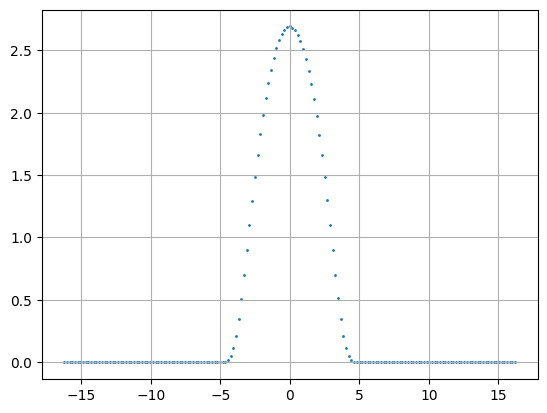

In [107]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()